# Análisis de componentes principales (PCA)

Este notebook introduce el uso de PCA (Principal Component Analysis) como herramienta para reducir la dimensionalidad de un conjunto de variables correlacionadas y para identificar las direcciones principales de variación en los datos.

PCA es especialmente útil cuando se trabaja con datos de alta dimensión o con variables que aportan información redundante. En lugar de conservar todas las variables originales, PCA genera combinaciones lineales ortogonales llamadas componentes principales, ordenadas por la cantidad de varianza que explican. La idea central es conservar la estructura esencial de los datos con menos dimensiones, manteniendo la mayor parte de la información estadística.

Para ilustrarlo usaremos el dataset Iris, un conjunto clásico y muy citado en el aprendizaje automático. Se analiza la estructura de sus variables, se aplica estandarización previa, se inspeccionan los componentes principales y se selecciona el número adecuado de dimensiones con criterios estadísticos bien definidos.

Referencias:
- UCI Iris: https://archive.ics.uci.edu/dataset/53/iris
- scikit-learn PCA: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html


## Objetivos de aprendizaje

Al finalizar este laboratorio podrás:

- explicar PCA como una transformación lineal que busca direcciones de máxima varianza;
- justificar la estandarización cuando las variables usan escalas diferentes;
- interpretar varianza explicada, loadings y scores en Iris, Old Faithful y Wholesale Customers;
- distinguir una proyección útil para visualizar de una reducción que conserve suficiente información para un análisis posterior.

## Problema y estrategia

En cada conjunto se busca representar observaciones con menos dimensiones y medir qué información se conserva. PCA no usa las etiquetas para construir los componentes; cuando aparecen clases o categorías en gráficos, se emplean únicamente para colorear y facilitar la interpretación posterior. Los tres conjuntos se analizan por separado porque tienen unidades y variables distintas.

In [36]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

SEMILLA = 42

In [37]:
def analizar_pca(X_std, umbral_varianza=0.80):
    pca = PCA(random_state=SEMILLA)
    X_pca = pca.fit_transform(X_std)
    var_exp = pca.explained_variance_ratio_
    var_acum = np.cumsum(var_exp)

    n_componentes_umbral = int(np.searchsorted(var_acum, umbral_varianza) + 1)
    n_componentes_umbral = max(1, min(n_componentes_umbral, len(var_exp)))

    n_elbow = 1
    if len(var_exp) > 1:
        n_elbow = int(np.argmax(np.diff(var_exp)) + 1)

    return {
        'modelo': pca,
        'proyeccion': X_pca,
        'varianza_explicada': var_exp,
        'varianza_acumulada': var_acum,
        'n_umbral': n_componentes_umbral,
        'n_elbow': n_elbow,
    }


def graficar_varianza_pca(varianza_explicada, varianza_acumulada, n_recomendado, umbral_varianza=0.80):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(range(1, len(varianza_explicada) + 1), varianza_explicada, marker='o', linestyle='-', color='#2b7bba')
    axes[0].axvline(n_recomendado, color='black', linestyle='--', linewidth=1.2)
    axes[0].set_title('Scree plot: varianza explicada por componente')
    axes[0].set_xlabel('Número de componente')
    axes[0].set_ylabel('Varianza explicada')

    axes[1].plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='-', color='#e07a1a')
    axes[1].axhline(umbral_varianza, color='gray', linestyle='--', linewidth=1)
    axes[1].axvline(n_recomendado, color='black', linestyle='--', linewidth=1.2)
    axes[1].set_title('Varianza acumulada')
    axes[1].set_xlabel('Número de componentes')
    axes[1].set_ylabel('Varianza acumulada')
    plt.tight_layout()


def cargar_loadings(pca_modelo, columnas):
    loadings = pca_modelo.components_.T
    return pd.DataFrame(loadings, index=columnas, columns=[f'PC{i + 1}' for i in range(loadings.shape[1])])


def interpretar_loadings(nombre, loadings, componentes=None):
    if componentes is None:
        componentes = list(range(1, loadings.shape[1] + 1))

    textos = []

    if nombre == 'Iris':
        for comp in componentes:
            col = f'PC{comp}'
            top = loadings[col].abs().sort_values(ascending=False)
            vars_top = top.index.tolist()[:3]
            if comp == 1:
                textos.append(
                    f"PC1 es la dirección de mayor variación y se consolida sobre {vars_top[0]}, {vars_top[1]} y {vars_top[2]}. En conjunto, esta componente resume la dimensión de tamaño general de la flor: a mayor valor de PC1, más grandes son las medidas de pétalo y sépalo."
                )
            elif comp == 2:
                textos.append(
                    f"PC2 recoge un contraste más sutil: {vars_top[0]} domina la carga mientras el resto de variables se comporta de manera más equilibrada. Esta componente distingue la forma del sépalo y el equilibrio entre ancho y longitud, mostrando que no todo el crecimiento es equivalente en todas las direcciones."
                )
            elif comp == 3:
                textos.append(
                    f"PC3 ya representa un efecto residual más específico. Aquí aparece una mezcla entre {vars_top[0]} y {vars_top[1]}, indicando que la tercera dimensión está capturando matices de forma que no pertenecen al eje principal de talla ni al eje de anchura del sépalo."
                )
            else:
                textos.append(
                    f"PC{comp} aporta una variación marginal y más localizada, con énfasis en {vars_top[0]} y {vars_top[1]}. A nivel interpretativo, esta componente ya no organiza la estructura global del conjunto, sino detalles menores de forma y proporción."
                )

    elif nombre == 'Old Faithful':
        for comp in componentes:
            col = f'PC{comp}'
            top = loadings[col].abs().sort_values(ascending=False)
            vars_top = top.index.tolist()[:2]
            if comp == 1:
                textos.append(
                    f"PC1 agrupa a {vars_top[0]} y {vars_top[1]} en la misma dirección, por lo que representa la tendencia general del ciclo: un aumento simultáneo de duración y de espera. Es la componente de intensidad del sistema."
                )
            else:
                textos.append(
                    f"PC{comp} es una dirección complementaria que describe la diferencia relativa entre {vars_top[0]} y {vars_top[1]}. No es un eje de tamaño general, sino un balance entre ambas variables."
                )

    elif nombre == 'Wholesale Customers':
        for comp in componentes:
            col = f'PC{comp}'
            top = loadings[col].abs().sort_values(ascending=False)
            vars_top = top.index.tolist()[:3]
            if comp == 1:
                textos.append(
                    f"PC1 está definida por {vars_top[0]}, {vars_top[1]} y {vars_top[2]}, todas con cargas alineadas en la misma dirección. Esto sugiere un eje general de volumen de compra y gasto operativo: clientes con valores altos en estas categorías aumentan la componente 1."
                )
            elif comp == 2:
                textos.append(
                    f"PC2 introduce un patrón más específico: {vars_top[0]}, {vars_top[1]} y {vars_top[2]} marcan una diferencia entre compras frescas y productos de almacén. Aquí se separan perfiles de consumo más ligados a frescos y congelados frente a la compra en volumen de productos de casa."
                )
            elif comp == 3:
                textos.append(
                    f"PC3 matiza aún más el comportamiento del cliente. Las cargas más altas apuntan a {vars_top[0]} y {vars_top[1]}, lo que sugiere que esta dimensión recoge un tipo de heterogeneidad más fina y menos general que la componente 1, asociado a una estructura de compra más especializada."
                )
            else:
                textos.append(
                    f"PC{comp} aporta una variación más residual, con énfasis en {vars_top[0]} y {vars_top[1]}. Es decir, ya no define el eje principal del comercio sino detalles específicos de composición del gasto."
                )

    else:
        for comp in componentes:
            col = f'PC{comp}'
            top = loadings[col].abs().sort_values(ascending=False)
            vars_top = top.index.tolist()[:3]
            textos.append(
                f"PC{comp} está dominada por {vars_top[0]}, {vars_top[1]} y {vars_top[2]}; estas variables indican la dirección principal que la componente captura dentro del conjunto."
            )

    return textos


def analizar_dataset_pca(nombre, X, target=None, transformar_log=False, columnas=None, umbral_varianza=0.80):
    X_proc = X.copy()
    if columnas is not None:
        X_proc = X_proc[columnas].copy()
    if transformar_log:
        X_proc = np.log1p(X_proc)

    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_proc)
    analisis = analizar_pca(X_std, umbral_varianza=umbral_varianza)

    print(f'\n=== {nombre} ===')
    print(f'Forma del dataset: {X_proc.shape}')
    print(f'Componentes recomendados con corte del 80% de varianza acumulada: {analisis["n_umbral"]}')
    print('Varianza explicada por cada componente principal:')
    print(pd.Series(analisis['varianza_explicada'], index=[f'PC{i + 1}' for i in range(len(analisis['varianza_explicada']))]).round(4).to_string())
    print('\nVarianza acumulada por componente:')
    print(pd.Series(analisis['varianza_acumulada'], index=[f'PC{i + 1}' for i in range(len(analisis['varianza_acumulada']))]).round(4).to_string())

    print(f'\nRegla práctica: se retiene la menor cantidad de componentes que alcance al menos {umbral_varianza:.0%} de la varianza acumulada: {analisis["n_umbral"]}.')
    print(f'El punto de inflexión observado en la curva sugiere que alrededor de {analisis["n_elbow"]} componentes captura la estructura dominante.')

    graficar_varianza_pca(analisis['varianza_explicada'], analisis['varianza_acumulada'], analisis['n_umbral'], umbral_varianza=umbral_varianza)

    loadings = cargar_loadings(analisis['modelo'], list(X_proc.columns))
    print('\nLoadings del PCA:')
    display(loadings.round(3))

    print('\nInterpretación de los loadings:')
    componentes_retenidas = list(range(1, analisis['n_umbral'] + 1))
    for linea in interpretar_loadings(nombre, loadings, componentes_retenidas):
        print(f'- {linea}')

    componentes = min(2, X_std.shape[1])
    coords = pd.DataFrame(analisis['proyeccion'][:, :componentes], columns=[f'PC{i + 1}' for i in range(componentes)])
    if target is not None:
        coords['target'] = target.reset_index(drop=True)

    if componentes == 2:
        fig, ax = plt.subplots(figsize=(8, 6))
        if target is not None:
            sns.scatterplot(data=coords, x='PC1', y='PC2', hue='target', palette='tab10', s=60, alpha=0.8, ax=ax)
        else:
            sns.scatterplot(data=coords, x='PC1', y='PC2', s=60, alpha=0.8, color='#2b7bba', ax=ax)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.axvline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_title(f'{nombre}: proyección en las dos primeras componentes principales')
        plt.tight_layout()

    var_acum_final = analisis['varianza_acumulada'][analisis['n_umbral'] - 1]
    print(f'\nInterpretación analítica: con {analisis["n_umbral"]} componente(s) se conserva aproximadamente {var_acum_final:.2%} de la información total.')
    print('Esto sugiere que la mayor parte de la estructura del conjunto ya está contenida en pocas dimensiones, sin necesidad de conservar todas las variables originales.')

    return {
        'X_std': X_std,
        'analisis': analisis,
        'loadings': loadings,
        'proyeccion': coords,
    }

## 1. Caso 1: Iris

Iris es el ejemplo clásico para entender qué hace PCA en la práctica. Aunque el conjunto tiene cuatro variables, la mayor parte de su forma estructural puede describirse con pocas combinaciones lineales; es decir, no hace falta conservar todas las medidas originales para captar la esencia del patrón.

Aquí se ve cómo la variabilidad se concentra en unas pocas direcciones y cómo el corte del 80% de varianza acumulada ayuda a decidir cuántas componentes conviene conservar.

In [38]:
iris = load_iris(as_frame=True)
X_iris = iris.data.copy()
y_iris = iris.target.copy()

resumen_iris = pd.DataFrame({
    'dataset': ['Iris'],
    'fuente': ['UCI / sklearn'],
    'observaciones': [X_iris.shape[0]],
    'variables': [X_iris.shape[1]],
    'clases_reales': [len(np.unique(y_iris))],
})

display(resumen_iris)
display(X_iris.head())
print(iris.DESCR.split('\n')[0])

,dataset,fuente,observaciones,variables,clases_reales
0,Iris,UCI / sklearn,150,4,3


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


.. _iris_dataset:



=== PCA para Iris ===
Forma del dataset: (150, 4)
Componentes recomendados con corte del 80% de varianza acumulada: 2
Varianza explicada por cada componente principal:
PC1    0.7296
PC2    0.2285
PC3    0.0367
PC4    0.0052

Varianza acumulada por componente:
PC1    0.7296
PC2    0.9581
PC3    0.9948
PC4    1.0000

Loadings del PCA de Iris:


,PC1,PC2,PC3,PC4
sepal length (cm),0.521,0.377,0.720,-0.261
sepal width (cm),-0.269,0.923,-0.244,0.124
petal length (cm),0.580,0.024,-0.142,0.801
petal width (cm),0.565,0.067,-0.634,-0.524


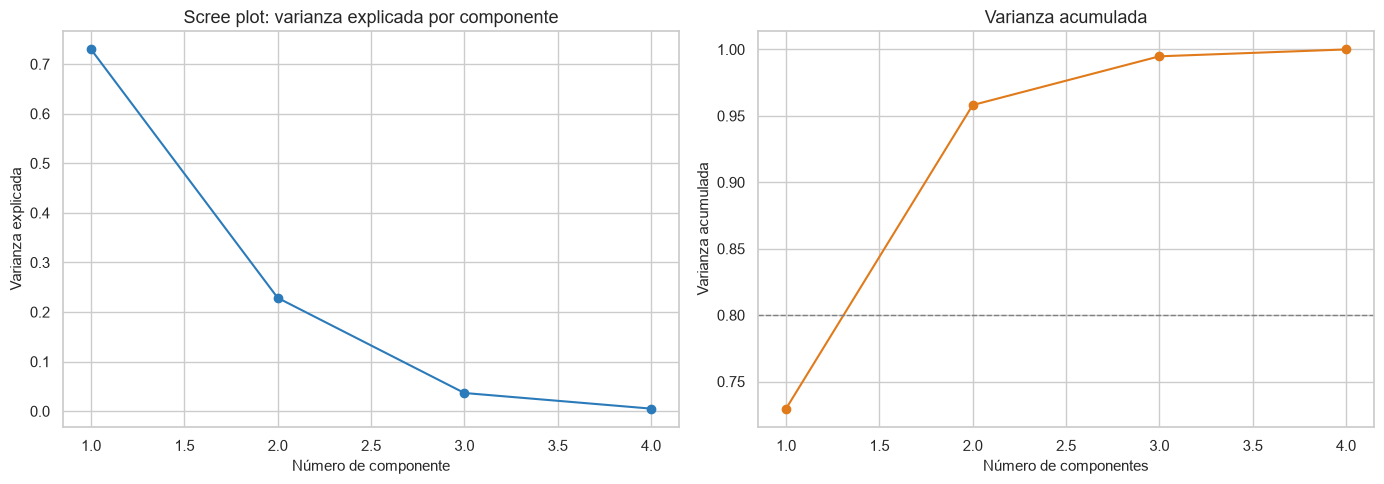

In [39]:
scaler_iris = StandardScaler()
X_iris_std = scaler_iris.fit_transform(X_iris)

pca_iris = PCA(random_state=SEMILLA)
X_iris_pca = pca_iris.fit_transform(X_iris_std)
var_iris = pca_iris.explained_variance_ratio_
var_iris_acum = np.cumsum(var_iris)

n_iris = int(np.searchsorted(var_iris_acum, 0.80) + 1)

print('\n=== PCA para Iris ===')
print(f'Forma del dataset: {X_iris.shape}')
print(f'Componentes recomendados con corte del 80% de varianza acumulada: {n_iris}')
print('Varianza explicada por cada componente principal:')
print(pd.Series(var_iris, index=[f'PC{i + 1}' for i in range(len(var_iris))]).round(4).to_string())
print('\nVarianza acumulada por componente:')
print(pd.Series(var_iris_acum, index=[f'PC{i + 1}' for i in range(len(var_iris_acum))]).round(4).to_string())

fig_iris, axes_iris = plt.subplots(1, 2, figsize=(14, 5))
axes_iris[0].plot(range(1, len(var_iris) + 1), var_iris, marker='o', linestyle='-', color='#2b7bba')
axes_iris[0].set_title('Scree plot: varianza explicada por componente')
axes_iris[0].set_xlabel('Número de componente')
axes_iris[0].set_ylabel('Varianza explicada')

axes_iris[1].plot(range(1, len(var_iris_acum) + 1), var_iris_acum, marker='o', linestyle='-', color='#e07a1a')
axes_iris[1].axhline(0.80, color='gray', linestyle='--', linewidth=1)
axes_iris[1].set_title('Varianza acumulada')
axes_iris[1].set_xlabel('Número de componentes')
axes_iris[1].set_ylabel('Varianza acumulada')
plt.tight_layout()

loadings_iris = pd.DataFrame(
    pca_iris.components_.T,
    index=X_iris.columns,
    columns=[f'PC{i + 1}' for i in range(pca_iris.n_components_)]
)
print('\nLoadings del PCA de Iris:')
display(loadings_iris.round(3))


Interpretación local de los loadings:
- PC1: está dominada por petal length (cm), petal width (cm) y sepal length (cm); reúne la dimensión general del tamaño de la flor y explica la mayor parte de la variación.
- PC2: se forma con un patrón más específico de forma, donde sepal width (cm) pesa mucho más que el resto; esto indica una diferencia entre anchura y longitud, especialmente en el sépalo.

Interpretación analítica: con 2 componente(s) se conserva aproximadamente 95.81% de la información total.


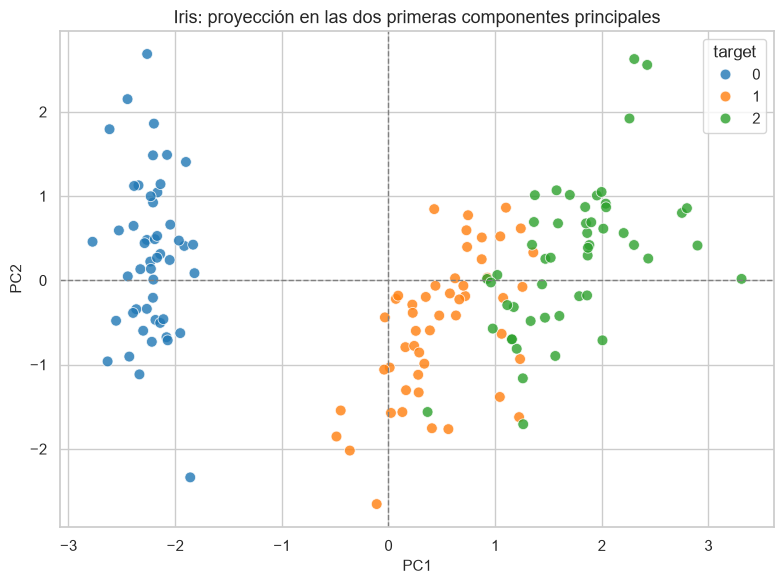

In [40]:
print('\nInterpretación local de los loadings:')
for comp in range(1, n_iris + 1):
    col = f'PC{comp}'
    top = loadings_iris[col].abs().sort_values(ascending=False)
    vars_top = top.index.tolist()[:3]
    if comp == 1:
        print(f'- {col}: está dominada por {vars_top[0]}, {vars_top[1]} y {vars_top[2]}; reúne la dimensión general del tamaño de la flor y explica la mayor parte de la variación.')
    elif comp == 2:
        print(f'- {col}: se forma con un patrón más específico de forma, donde {vars_top[0]} pesa mucho más que el resto; esto indica una diferencia entre anchura y longitud, especialmente en el sépalo.')
    else:
        print(f'- {col}: aporta una variación residual, con énfasis en {vars_top[0]} y {vars_top[1]}; refleja matices secundarios de proporción y forma más que la estructura global.')

coords_iris = pd.DataFrame(X_iris_pca[:, :2], columns=['PC1', 'PC2'])
coords_iris['target'] = y_iris.reset_index(drop=True)
fig_iris2, ax_iris2 = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=coords_iris, x='PC1', y='PC2', hue='target', palette='tab10', s=60, alpha=0.8, ax=ax_iris2)
ax_iris2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_iris2.axvline(0, color='gray', linestyle='--', linewidth=1)
ax_iris2.set_title('Iris: proyección en las dos primeras componentes principales')
plt.tight_layout()

print(f'\nInterpretación analítica: con {n_iris} componente(s) se conserva aproximadamente {var_iris_acum[n_iris - 1]:.2%} de la información total.')

## 2. Caso 2: Old Faithful Geyser

Old Faithful parece, a primera vista, un problema de dos variables y poco misterio. Sin embargo, PCA permite mirar más allá de la intuición visual: identifica la combinación lineal que concentra la mayor parte del movimiento del sistema y nos dice cuántas direcciones reales son necesarias para resumir la variación observada.

Es un ejemplo útil para mostrar que la reducción de dimensionalidad no es solo una técnica de compresión, sino también una forma de leer la estructura geométrica de los datos.

In [41]:
geyser = pd.read_csv('https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv')
geyser = geyser.drop(columns=['rownames'])
X_geyser = geyser[['eruptions', 'waiting']].copy()

resumen_geyser = pd.DataFrame({
    'dataset': ['Old Faithful'],
    'fuente': ['R datasets / Rdatasets'],
    'observaciones': [X_geyser.shape[0]],
    'variables': [X_geyser.shape[1]],
})

display(resumen_geyser)
display(X_geyser.head())

,dataset,fuente,observaciones,variables
0,Old Faithful,R datasets / Rdatasets,272,2


,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85



=== PCA para Old Faithful ===
Forma del dataset: (272, 2)
Componentes recomendados con corte del 80% de varianza acumulada: 1
Varianza explicada por cada componente principal:
PC1    0.9504
PC2    0.0496

Varianza acumulada por componente:
PC1    0.9504
PC2    1.0000

Loadings del PCA de Old Faithful:


,PC1,PC2
eruptions,0.707,-0.707
waiting,0.707,0.707


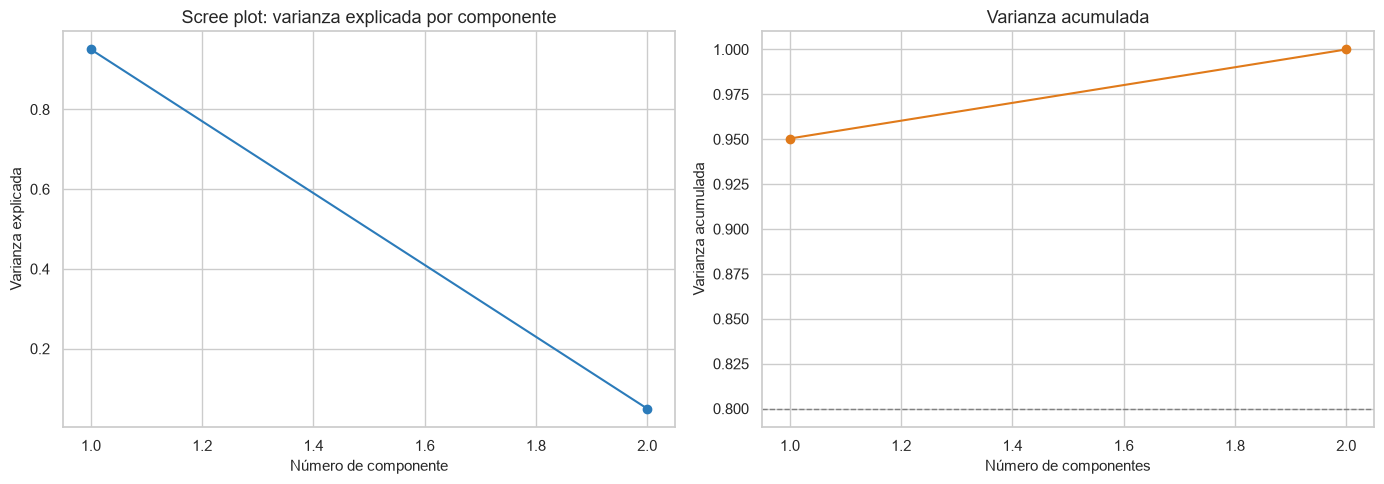

In [42]:
scaler_geyser = StandardScaler()
X_geyser_std = scaler_geyser.fit_transform(X_geyser)

pca_geyser = PCA(random_state=SEMILLA)
X_geyser_pca = pca_geyser.fit_transform(X_geyser_std)
var_geyser = pca_geyser.explained_variance_ratio_
var_geyser_acum = np.cumsum(var_geyser)

n_geyser = int(np.searchsorted(var_geyser_acum, 0.80) + 1)

print('\n=== PCA para Old Faithful ===')
print(f'Forma del dataset: {X_geyser.shape}')
print(f'Componentes recomendados con corte del 80% de varianza acumulada: {n_geyser}')
print('Varianza explicada por cada componente principal:')
print(pd.Series(var_geyser, index=[f'PC{i + 1}' for i in range(len(var_geyser))]).round(4).to_string())
print('\nVarianza acumulada por componente:')
print(pd.Series(var_geyser_acum, index=[f'PC{i + 1}' for i in range(len(var_geyser_acum))]).round(4).to_string())

fig_geyser, axes_geyser = plt.subplots(1, 2, figsize=(14, 5))
axes_geyser[0].plot(range(1, len(var_geyser) + 1), var_geyser, marker='o', linestyle='-', color='#2b7bba')
axes_geyser[0].set_title('Scree plot: varianza explicada por componente')
axes_geyser[0].set_xlabel('Número de componente')
axes_geyser[0].set_ylabel('Varianza explicada')

axes_geyser[1].plot(range(1, len(var_geyser_acum) + 1), var_geyser_acum, marker='o', linestyle='-', color='#e07a1a')
axes_geyser[1].axhline(0.80, color='gray', linestyle='--', linewidth=1)
axes_geyser[1].set_title('Varianza acumulada')
axes_geyser[1].set_xlabel('Número de componentes')
axes_geyser[1].set_ylabel('Varianza acumulada')
plt.tight_layout()

loadings_geyser = pd.DataFrame(
    pca_geyser.components_.T,
    index=X_geyser.columns,
    columns=[f'PC{i + 1}' for i in range(pca_geyser.n_components_)]
)
print('\nLoadings del PCA de Old Faithful:')
display(loadings_geyser.round(3))


Interpretación local de los loadings:
- PC1: agrupa a eruptions y waiting en la misma dirección; representa la intensidad general del ciclo, donde el aumento de una variable va acompañado del aumento de la otra.

Interpretación analítica: con 1 componente(s) se conserva aproximadamente 95.04% de la información total.


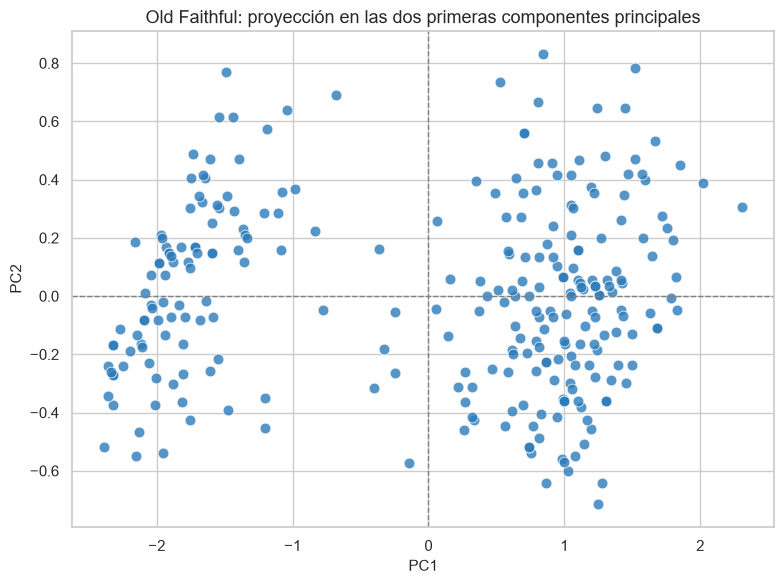

In [43]:
print('\nInterpretación local de los loadings:')
for comp in range(1, n_geyser + 1):
    col = f'PC{comp}'
    top = loadings_geyser[col].abs().sort_values(ascending=False)
    vars_top = top.index.tolist()[:2]
    if comp == 1:
        print(f'- {col}: agrupa a {vars_top[0]} y {vars_top[1]} en la misma dirección; representa la intensidad general del ciclo, donde el aumento de una variable va acompañado del aumento de la otra.')
    else:
        print(f'- {col}: introduce un contraste más específico entre {vars_top[0]} y {vars_top[1]}; aquí la componente ya no resume el tamaño global del sistema, sino el balance relativo entre ambas medidas.')

coords_geyser = pd.DataFrame(X_geyser_pca[:, :2], columns=['PC1', 'PC2'])
fig_geyser2, ax_geyser2 = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=coords_geyser, x='PC1', y='PC2', s=60, alpha=0.8, color='#2b7bba', ax=ax_geyser2)
ax_geyser2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_geyser2.axvline(0, color='gray', linestyle='--', linewidth=1)
ax_geyser2.set_title('Old Faithful: proyección en las dos primeras componentes principales')
plt.tight_layout()

print(f'\nInterpretación analítica: con {n_geyser} componente(s) se conserva aproximadamente {var_geyser_acum[n_geyser - 1]:.2%} de la información total.')

## 3. Caso 3: Wholesale Customers

El dataset de clientes mayoristas es más rico y más desordenado. Aquí hay muchas variables de gasto, algunas claramente relacionadas entre sí. PCA nos ayuda a preguntar: ¿cuánta de esta riqueza se puede resumir en un puñado de dimensiones? La respuesta no viene solo de la intuición, sino del criterio cuantitativo de varianza acumulada.

El punto de corte fijado en 80% funciona como un criterio práctico: si con pocas componentes ya capturamos la mayor parte de la variación, entonces esas dimensiones son suficientes para describir la estructura general del conjunto.

In [44]:
wholesale = fetch_ucirepo(id=292)
wholesale_X = wholesale.data.features.copy()
columnas_modelo = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
wholesale_numerico = wholesale_X[columnas_modelo].copy()

resumen_wholesale = pd.DataFrame({
    'dataset': ['Wholesale Customers'],
    'fuente': ['UCI'],
    'observaciones': [wholesale_X.shape[0]],
    'variables_modelo': [wholesale_numerico.shape[1]],
    'variables_totales': [wholesale_X.shape[1]],
})

display(resumen_wholesale)
display(wholesale_X.head())

,dataset,fuente,observaciones,variables_modelo,variables_totales
0,Wholesale Customers,UCI,440,6,7


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185



=== PCA para Wholesale Customers ===
Forma del dataset: (440, 6)
Componentes recomendados con corte del 80% de varianza acumulada: 3
Varianza explicada por cada componente principal:
PC1    0.4408
PC2    0.2719
PC3    0.1070
PC4    0.1010
PC5    0.0488
PC6    0.0305

Varianza acumulada por componente:
PC1    0.4408
PC2    0.7127
PC3    0.8197
PC4    0.9207
PC5    0.9695
PC6    1.0000

Loadings del PCA de Wholesale Customers:


,PC1,PC2,PC3,PC4,PC5,PC6
Fresh,-0.105,0.590,-0.640,-0.479,-0.040,0.026
Milk,0.542,0.133,-0.074,0.062,0.760,-0.319
Grocery,0.571,-0.006,-0.133,0.097,-0.093,0.799
Frozen,-0.138,0.590,-0.021,0.792,-0.073,-0.005
Detergents_Paper,0.551,-0.071,-0.200,0.083,-0.620,-0.510
Delicassen,0.214,0.530,0.726,-0.352,-0.148,-0.003


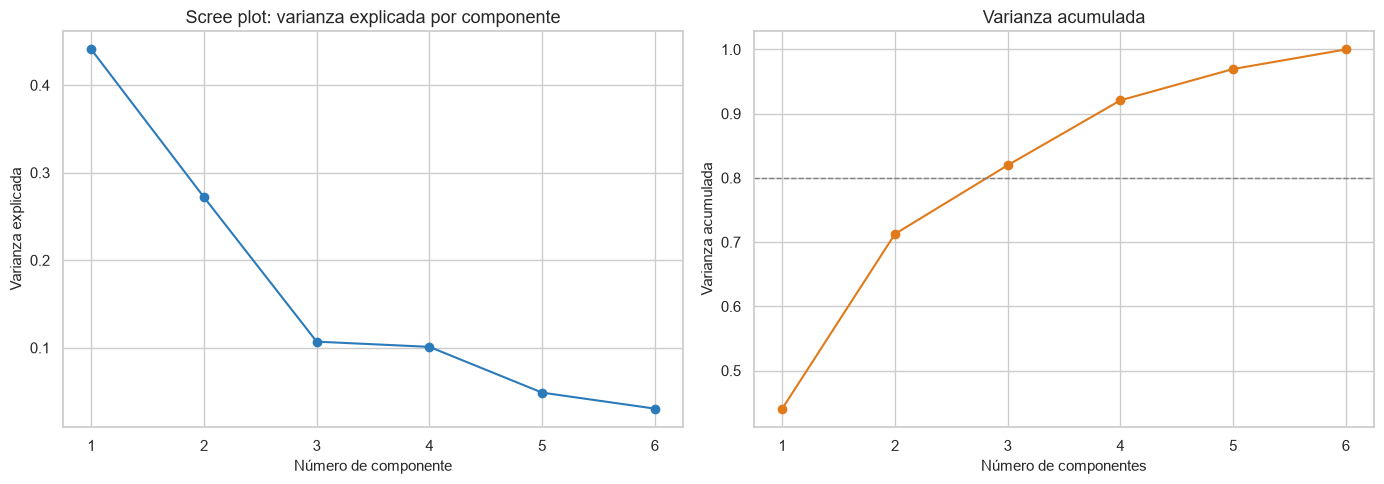

In [45]:
wholesale_log = np.log1p(wholesale_numerico)
scaler_wholesale = StandardScaler()
X_wholesale_std = scaler_wholesale.fit_transform(wholesale_log)

pca_wholesale = PCA(random_state=SEMILLA)
X_wholesale_pca = pca_wholesale.fit_transform(X_wholesale_std)
var_wholesale = pca_wholesale.explained_variance_ratio_
var_wholesale_acum = np.cumsum(var_wholesale)

n_wholesale = int(np.searchsorted(var_wholesale_acum, 0.80) + 1)

print('\n=== PCA para Wholesale Customers ===')
print(f'Forma del dataset: {wholesale_log.shape}')
print(f'Componentes recomendados con corte del 80% de varianza acumulada: {n_wholesale}')
print('Varianza explicada por cada componente principal:')
print(pd.Series(var_wholesale, index=[f'PC{i + 1}' for i in range(len(var_wholesale))]).round(4).to_string())
print('\nVarianza acumulada por componente:')
print(pd.Series(var_wholesale_acum, index=[f'PC{i + 1}' for i in range(len(var_wholesale_acum))]).round(4).to_string())

fig_wholesale, axes_wholesale = plt.subplots(1, 2, figsize=(14, 5))
axes_wholesale[0].plot(range(1, len(var_wholesale) + 1), var_wholesale, marker='o', linestyle='-', color='#2b7bba')
axes_wholesale[0].set_title('Scree plot: varianza explicada por componente')
axes_wholesale[0].set_xlabel('Número de componente')
axes_wholesale[0].set_ylabel('Varianza explicada')

axes_wholesale[1].plot(range(1, len(var_wholesale_acum) + 1), var_wholesale_acum, marker='o', linestyle='-', color='#e07a1a')
axes_wholesale[1].axhline(0.80, color='gray', linestyle='--', linewidth=1)
axes_wholesale[1].set_title('Varianza acumulada')
axes_wholesale[1].set_xlabel('Número de componentes')
axes_wholesale[1].set_ylabel('Varianza acumulada')
plt.tight_layout()

loadings_wholesale = pd.DataFrame(
    pca_wholesale.components_.T,
    index=wholesale_numerico.columns,
    columns=[f'PC{i + 1}' for i in range(pca_wholesale.n_components_)]
)
print('\nLoadings del PCA de Wholesale Customers:')
display(loadings_wholesale.round(3))


Interpretación local de los loadings:
- PC1: está definida por Grocery, Detergents_Paper y Milk; describe el volumen total de consumo y el gasto operativo general del cliente.
- PC2: captura un contraste entre compras de productos frescos y de consumo doméstico; refleja perfiles de gasto más orientados a alimentos frescos o a productos de almacén.
- PC3: refleja una variación más específica y residual, con énfasis en Delicassen y Fresh; señala diferencias de composición del gasto más que un eje global del volumen.

Interpretación analítica: con 3 componente(s) se conserva aproximadamente 81.97% de la información total.


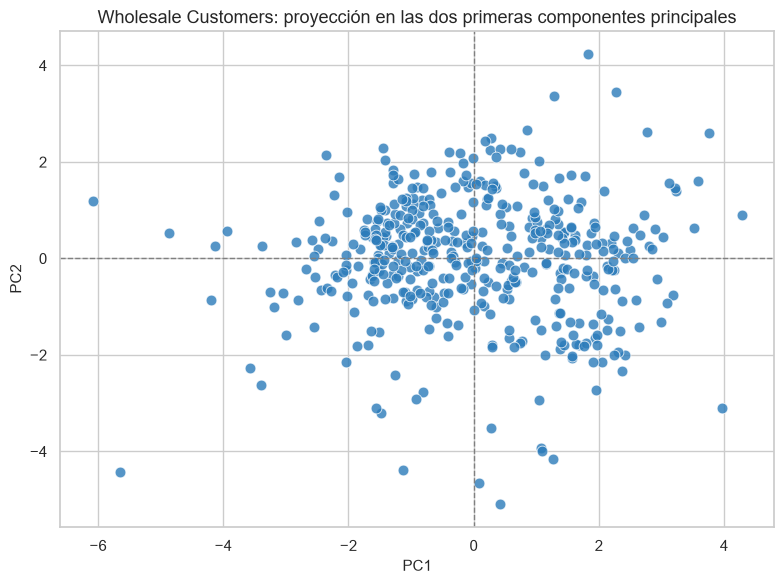

In [46]:
print('\nInterpretación local de los loadings:')
for comp in range(1, n_wholesale + 1):
    col = f'PC{comp}'
    top = loadings_wholesale[col].abs().sort_values(ascending=False)
    vars_top = top.index.tolist()[:3]
    if comp == 1:
        print(f'- {col}: está definida por {vars_top[0]}, {vars_top[1]} y {vars_top[2]}; describe el volumen total de consumo y el gasto operativo general del cliente.')
    elif comp == 2:
        print(f'- {col}: captura un contraste entre compras de productos frescos y de consumo doméstico; refleja perfiles de gasto más orientados a alimentos frescos o a productos de almacén.')
    else:
        print(f'- {col}: refleja una variación más específica y residual, con énfasis en {vars_top[0]} y {vars_top[1]}; señala diferencias de composición del gasto más que un eje global del volumen.')

coords_wholesale = pd.DataFrame(X_wholesale_pca[:, :2], columns=['PC1', 'PC2'])
fig_wholesale2, ax_wholesale2 = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=coords_wholesale, x='PC1', y='PC2', s=60, alpha=0.8, color='#2b7bba', ax=ax_wholesale2)
ax_wholesale2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_wholesale2.axvline(0, color='gray', linestyle='--', linewidth=1)
ax_wholesale2.set_title('Wholesale Customers: proyección en las dos primeras componentes principales')
plt.tight_layout()

print(f'\nInterpretación analítica: con {n_wholesale} componente(s) se conserva aproximadamente {var_wholesale_acum[n_wholesale - 1]:.2%} de la información total.')

## Conclusión

Este notebook no busca explicar clustering ni una segmentación por grupos. Su propósito es más claro y más elemental: mostrar cómo PCA permite ver la estructura interna de los datos, ordenar sus direcciones principales por varianza y decidir, con criterio, cuántas dimensiones conviene conservar.

La regla que usamos aquí es sencilla y práctica: tomamos el menor número de componentes cuya varianza acumulada supere el 80%. Esa decisión no es arbitraria; responde a la idea de que una reducción útil debe conservar la mayor parte de la información sin caer en una pérdida innecesaria de detalle.

En cada caso, la interpretación no termina en el número, sino en la lectura del sentido de esas componentes: qué variables contribuyen más, qué dirección domina la variación y qué tan bien el conjunto puede resumirse sin perder su estructura principal.

## Conclusiones

Resume cuánta varianza retienen los componentes seleccionados en cada caso y qué variables contribuyen a ellos. Los signos de los loadings pueden invertirse sin cambiar la interpretación geométrica; interpreta magnitudes y patrones relativos, no el signo aislado. Una buena proyección visual no demuestra que todos los grupos estén separados en el espacio original.

## Ejercicios propuestos

1. **Conceptual:** explica por qué escalar las variables cambia la dirección de los componentes.
2. **Implementación:** ajusta PCA sin limitar componentes y grafica la varianza explicada acumulada.
3. **Experimentación:** compara dos umbrales de varianza acumulada y cuenta cuántas dimensiones requiere cada conjunto.
4. **Análisis:** interpreta los loadings de los dos primeros componentes y contrástalos con los scores.
5. **Desafío:** propone una variable o medición que se perdería al reducir dimensión y discute cuándo esa pérdida sería relevante.

## Referencias

- [PCA en scikit-learn](https://scikit-learn.org/stable/modules/decomposition.html#pca)
- Jolliffe, I. T. y Cadima, J. (2016). Principal component analysis: a review and recent developments. *Philosophical Transactions of the Royal Society A*, 374(2065), 20150202. https://doi.org/10.1098/rsta.2015.0202
- [Iris en UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/53/iris)
- [Wholesale Customers en UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/292/wholesale+customers)
